## INTRODUCTION
This project utilises a machine learning technique to analyze a rich customer dataset sourced from Kaggle https://www.kaggle.com/datasets/datascientistanna/customers-dataset and derive valuable insights to help businesses optimize their customer engagement strategies. 

### The dataset contains 2000 entries and 8 attributes, including:

- Customer ID
- Gender
- Age
- Annual Income
- Spending Score: This score reflects the customer's spending behavior and patterns, as assigned by the shop.
- Profession
- Work Experience (in years)
- Family Size

### Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from math import sqrt

### Data Import

In [2]:
dataset = pd.read_csv("..\Data\Customers.csv")

### Data Cleaning and Preprocessing

In [3]:
dataset.head(0-100)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6
...,...,...,...,...,...,...,...,...
1895,1896,Male,75,132993,55,Entertainment,8,2
1896,1897,Female,65,72313,36,Lawyer,1,5
1897,1898,Female,30,84885,9,Entertainment,6,5
1898,1899,Male,46,126228,95,Marketing,8,2


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [5]:
# Check for missing values. 
dataset.isnull().sum()

CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

In [6]:
dataset.drop_duplicates(inplace=True)

In [7]:
dataset.dropna(inplace=True)

### Data Exploration and Visualization

Female    1166
Male       799
Name: Gender, dtype: int64


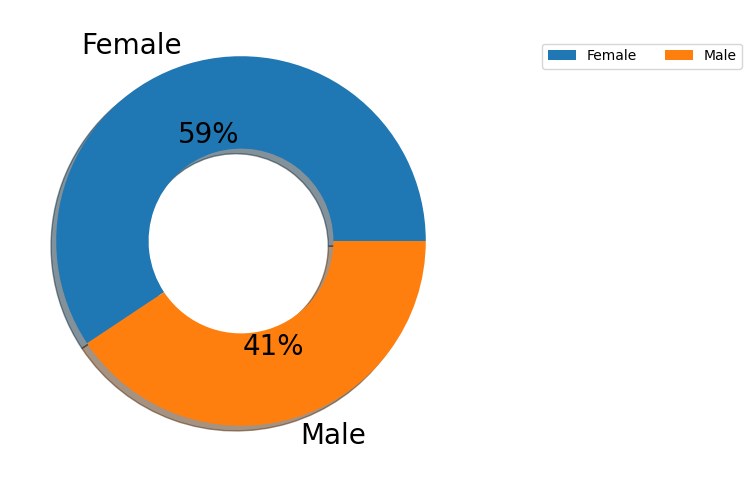

In [8]:
# Create a pencentage pie chart 'Gender Count' 
plt.figure(figsize = (8, 6))
g = dataset['Gender'].value_counts()
print(g)
plt.pie(g, labels = dataset["Gender"].value_counts().index, autopct = "%0.0f%%", 
        shadow = True, wedgeprops = {"width":0.5}, textprops = {"fontsize":20})
plt.legend(loc="center right",bbox_to_anchor=(1.6, 0.9),ncol=2,)


***Observation:***
The percentage pie chart provides a visual representation of the gender distribution in the dataset. The chart shows that there are 1166 females and 799 males, accounting for 59% and 41% of the total, respectively.

(array([0, 1]), [Text(0, 0, 'Male'), Text(1, 0, 'Female')])

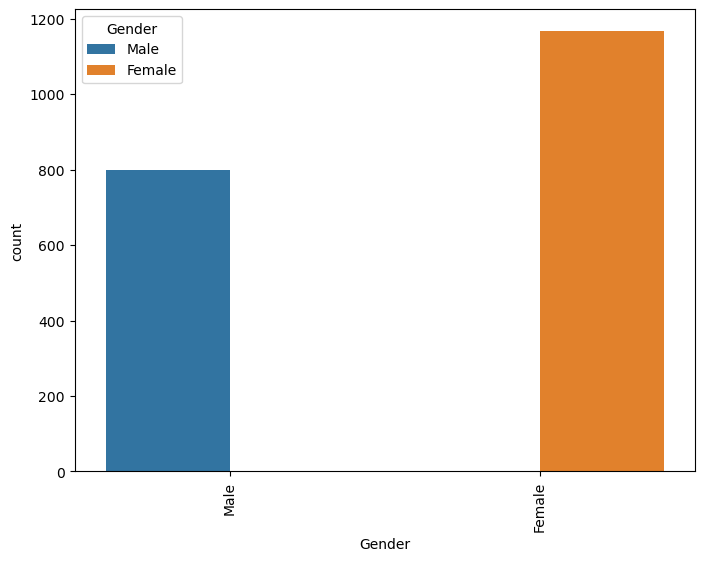

In [9]:
# Create a count plot 'Gender Count'
plt.figure(figsize = (8, 6))
sns.countplot(data = dataset, x = 'Gender', hue = 'Gender')
plt.xticks(rotation= 90)

***Observation:***
The count plot, provides another representation of the gender distribution. It shows two bars, indicating the count of males and females in the dataset.

In [10]:
#Visualise all unique profession
print(dataset['Profession'].unique())

['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing']


(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Healthcare'),
  Text(1, 0, 'Engineer'),
  Text(2, 0, 'Lawyer'),
  Text(3, 0, 'Entertainment'),
  Text(4, 0, 'Artist'),
  Text(5, 0, 'Executive'),
  Text(6, 0, 'Doctor'),
  Text(7, 0, 'Homemaker'),
  Text(8, 0, 'Marketing')])

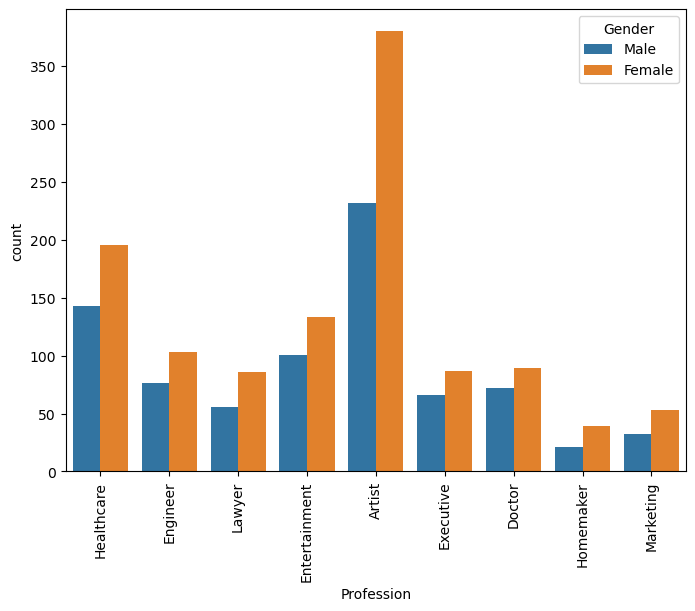

In [11]:
# Create a count plot 'Gender Count'
plt.figure(figsize = (8, 6))
sns.countplot(data = dataset, x = 'Profession', hue = 'Gender')
plt.xticks(rotation= 90)

***Observation:*** The count plot visually represents the distribution of genders across different professions, allowing for a comparison of gender representation within each profession.

<AxesSubplot:xlabel='Profession', ylabel='Annual Income ($)'>

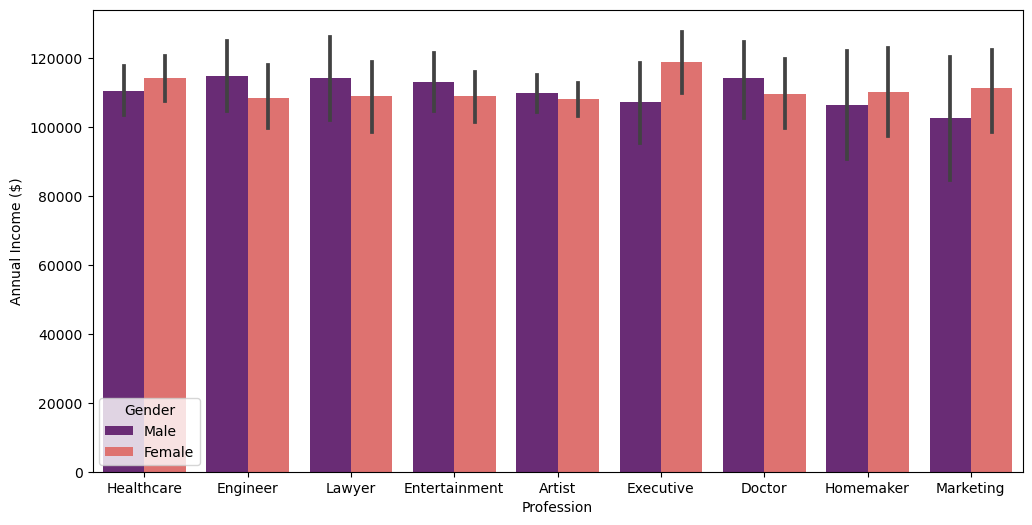

In [12]:
# Create a bar plot 'Profession with heighest income and gender'
plt.figure(figsize = (12, 6))
sns.barplot(data = dataset, y = 'Annual Income ($)', x = 'Profession', hue = 'Gender', palette = 'magma')

***Observation:***
The bar plot visually represents the average annual income for each profession, with the bars colored according to gender.

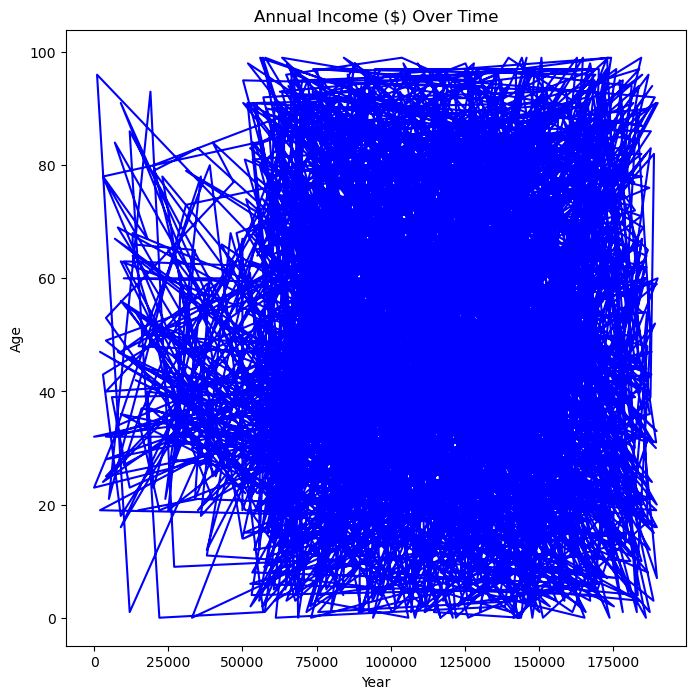

In [13]:
# Create a line plot 'Annual Income ($) and Age'
fig = plt.figure(figsize=(8, 8))
plt.plot(dataset['Annual Income ($)'], dataset['Age'], color='blue')
plt.title('Annual Income ($) Over Time')
plt.xlabel('Year')
plt.ylabel('Age')
plt.show()

***Observation:***
The line plot helps visualize the trend or correlation between annual income and age, showing how income changes with age over time.

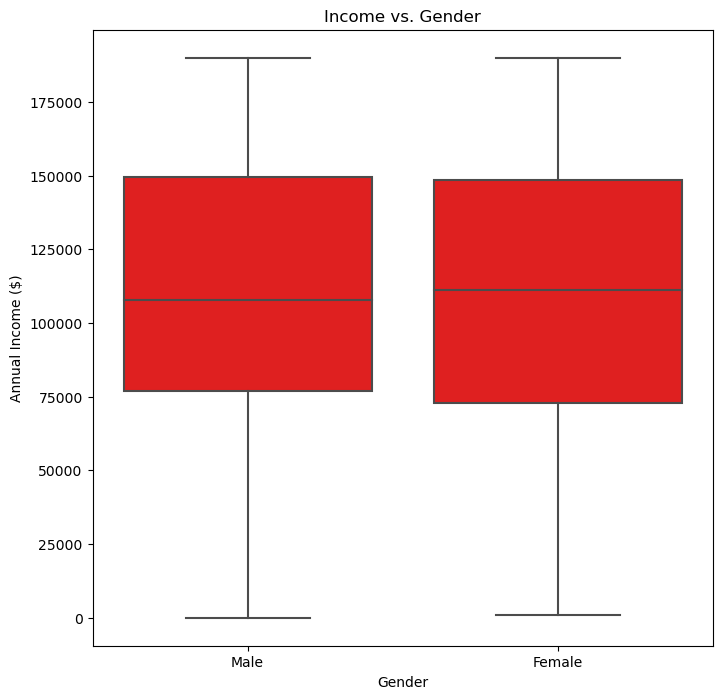

In [14]:
# Create a box plot 'Annual Income ($) and Gender'
fig = plt.figure(figsize=(8, 8))
sns.boxplot(x=dataset['Gender'], y=dataset['Annual Income ($)'], color='red')
plt.title('Income vs. Gender')
plt.xlabel('Gender')
plt.ylabel('Annual Income ($)')
plt.show()

***Observation:***
The box plot provides a visual representation of the distribution of annual income for each gender category.
The income disparities or variations between genders can be compared through the box plots.

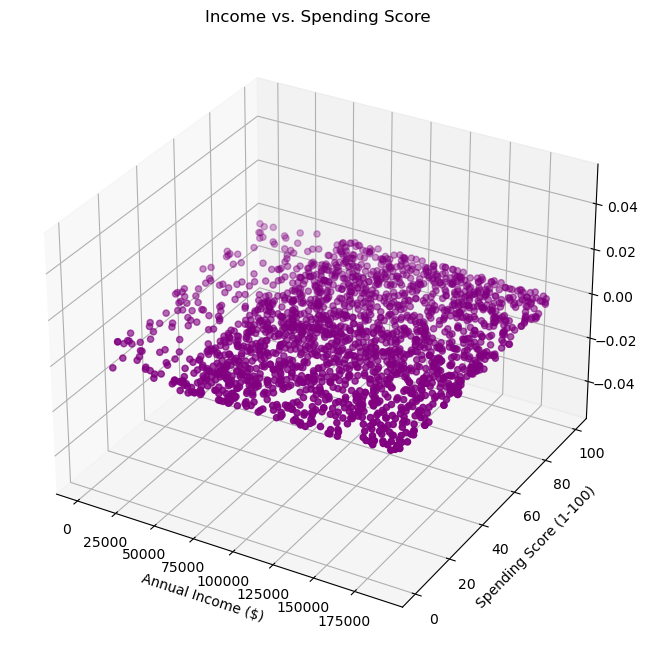

In [15]:
#Create a 3D Scatter plot 'Annual Income ($) and Spending Score (1-100)'
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dataset['Annual Income ($)'], dataset['Spending Score (1-100)'], color='purple')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Spending Score (1-100)')
plt.title('Income vs. Spending Score')
plt.show()

***Observation:***
The 3D scatter plot displays the relationship between the annual income and spending score for each data point. It identify any clusters or patterns in the data and understand how the two variables are related in a three-dimensional space.

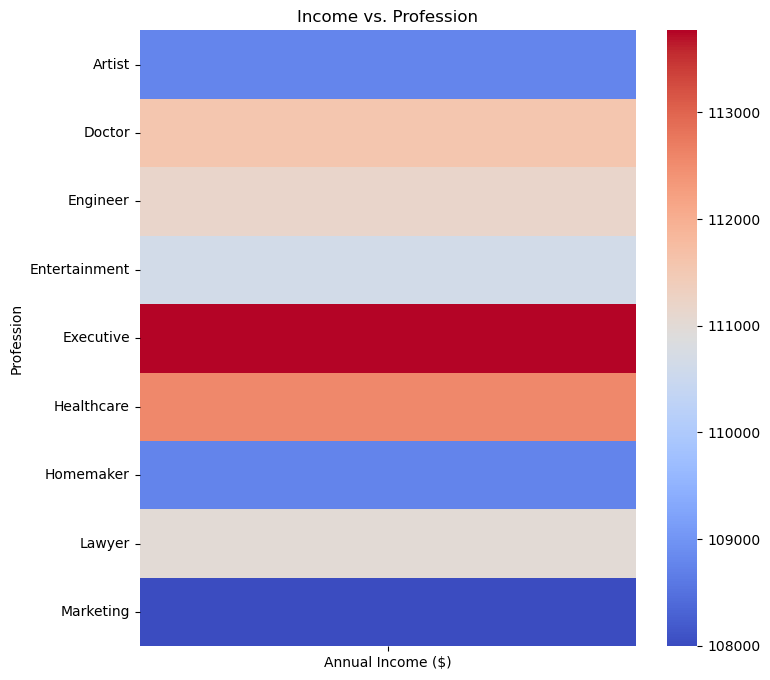

In [16]:
# Create a heatmap 'Annual Income ($) and Profession'
fig = plt.figure(figsize=(8, 8))
pivot = pd.pivot_table(dataset, values='Annual Income ($)', index=['Profession'])
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Income vs. Profession')
plt.ylabel('Profession')
plt.show()

***Observation:***
From the heatmap we can identify any patterns or variations in income across different professions. It provides insights into which professions tend to have higher or lower incomes and can be used for further analysis or decision-making.

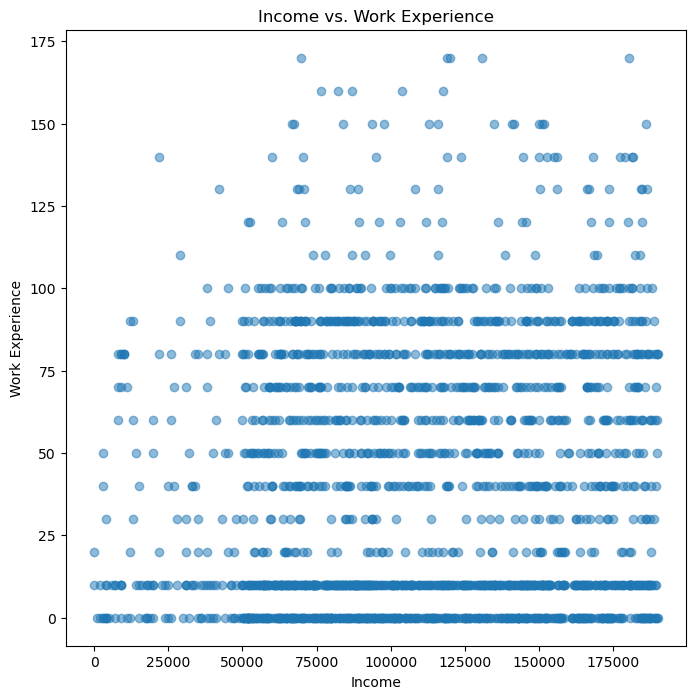

In [17]:
fig = plt.figure(figsize=(8, 8))
plt.scatter(dataset['Annual Income ($)'], dataset['Work Experience']*10, alpha=0.5)
plt.title('Income vs. Work Experience')
plt.xlabel('Income')
plt.ylabel('Work Experience')
plt.show()

***Observation:*** Based on the scatter plot, 
- The distribution of data points indicates the relationship between income and work experience.
- The spread of points in the plot visualize any patterns, clusters, or outliers in the data.
- The scatter plot provide insights into whether there is a correlation between income and work experience, such as identifying if individuals with higher work experience tend to have higher incomes or vice versa.
- The transparency level (alpha) of the points visualizes the overlapping data points, providing a sense of density in specific areas.
- By multiplying the 'Work Experience' values by 10 on the y-axis, the scale of work experience is expanded for better visualization, although the actual values remain unchanged.

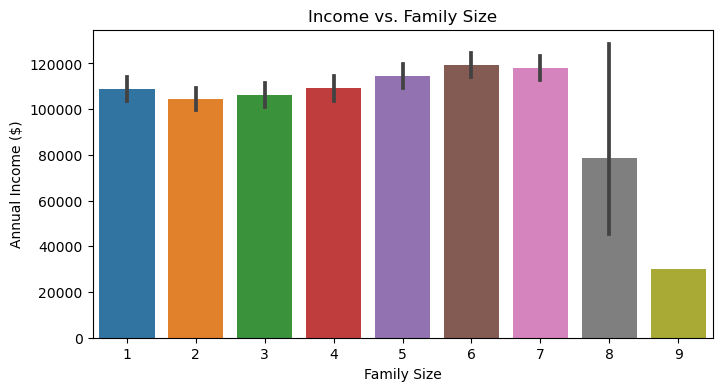

In [18]:
# Create a histogram 'Annual Income ($) and Family Size'
fig = plt.figure(figsize=(8, 4))
sns.barplot(data = dataset, y ='Annual Income ($)', x = 'Family Size')
plt.title('Income vs. Family Size')
plt.xlabel('Family Size')
plt.ylabel('Annual Income ($)')
plt.show()

***Observation:***
The histogram provides a visual representation of the distribution of annual income for different family sizes.
Each bar in the plot represents the average annual income for a particular family size category.
The plot displays the relationship between family size and income, such as whether larger families tend to have higher or lower incomes, or if there are any variations in income based on family size.

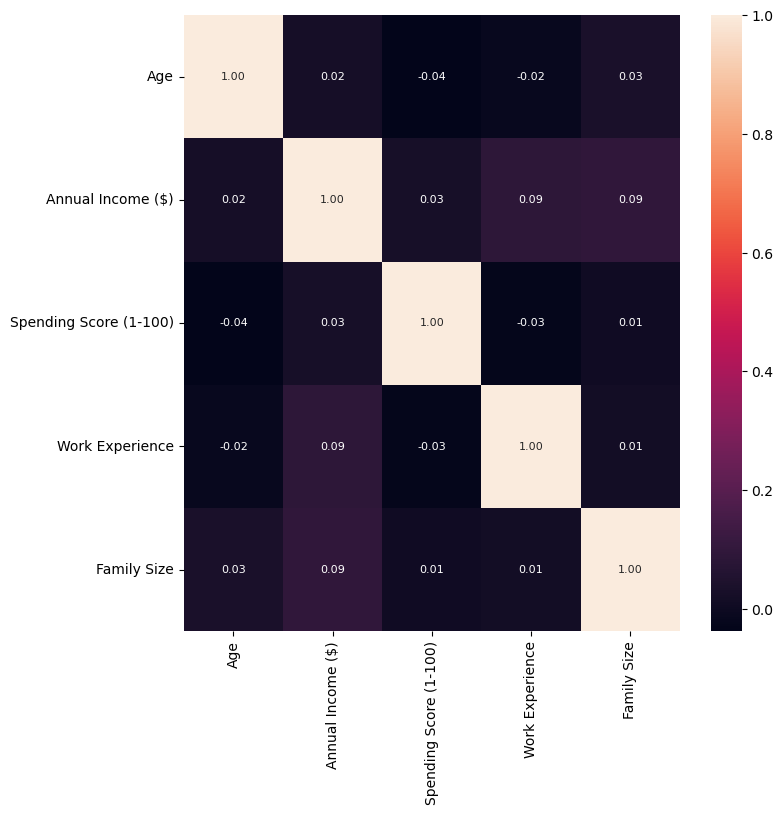

In [19]:
# Compute the correlation matrix
plt.figure(figsize = (8, 8))
corr_matrix = dataset[['Gender', 'Age','Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size']].corr()
sns.heatmap(corr_matrix, annot=True, fmt = '.2f', annot_kws = {'size': 8}, vmax= 1)
plt.show()

***Observation:***
The resulting heatmap provides a visual representation of the correlation between different variables in the dataset.
Positive correlations are indicated by lighter shades, while negative correlations are indicated by darker shades.
The heatmap shows relationships between variables useful for feature selection or understanding the impact of variables on each other.

### Convert string values to float values 'Gender' and 'Profession'

In [20]:
# Convert string to float 'Geneder'
dataset["Gender"].replace({'Male': 1,'Female': 0,}, inplace=True)

In [21]:
dataset.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,1,19,15000,39,Healthcare,1,4
1,2,1,21,35000,81,Engineer,3,3
2,3,0,20,86000,6,Engineer,1,1
3,4,0,23,59000,77,Lawyer,0,2
4,5,0,31,38000,40,Entertainment,2,6


In [22]:
# Convert string to float 'Profession'
dataset["Profession"].replace({'Healthcare': 0,
                            'Engineer': 1,
                            'Lawyer': 2,
                            'Entertainment': 3,
                            'Artist': 4,
                            'Executive': 5,
                            'Doctor': 6,
                            'Homemaker': 7,
                            'Marketing': 8,}, inplace=True)

In [23]:
dataset.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,1,19,15000,39,0,1,4
1,2,1,21,35000,81,1,3,3
2,3,0,20,86000,6,1,1,1
3,4,0,23,59000,77,2,0,2
4,5,0,31,38000,40,3,2,6


***Observation***
By converting the string values of 'Gender' and 'Profession' to float values, we prepares the data for our numerical analysis and modeling tasks. This transformation is useful as we are working with machine learning algorithms that require numerical input. Assigning numerical values to categories like gender and profession allows algorithms to process the data effectively. In this case, 'Male' is represented as 1 and 'Female' as 0. 'Healthcare' is represented as 0, 'Engineer' as 1, 'Lawyer' as 2, 'Entertainment' as 3, 'Artist' as 4, 'Executives' as 5, 'Doctor' as 6, 'Homemaker'as 7, and 'Marketing' as 8, which can enable further analysis or modeling based on gender and profession-related patterns or predictions.

# Apply Model

#### Predicting Spending Score (1-100) based on the money spent and the behavior of the customer

## 1. Linear Regression

In [24]:
# Select the features and target variable
X = dataset[['Gender', 'Age', 'Annual Income ($)', 'Profession', 'Work Experience', 'Family Size']]
y = dataset['Spending Score (1-100)']

In [25]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Fit the linear regression model
lr_model = LinearRegression(copy_X = False, fit_intercept = False, normalize = False)
lr_model.fit(X_train, y_train)

C:\Users\RIMO\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:148: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2. Please leave the normalize parameter to its default value to silence this warning. The default behavior of this estimator is to not do any normalization. If normalization is needed please use sklearn.preprocessing.StandardScaler instead.
  warnings.warn(


LinearRegression(copy_X=False, fit_intercept=False, normalize=False)

In [27]:
# Predict on the test set
lr_y_pred = lr_model.predict(X_test)

In [28]:
# Calculate the mean squared error
mse = mean_squared_error(y_test, lr_y_pred)
print(f'Mean squared error: {mse}')
lr_r2_score = r2_score(y_test, lr_y_pred)
print(f'R2 Score: {lr_r2_score}')
lr_rmse= sqrt(mse)
print(f'Root mean squared error: {lr_rmse}')
# Calculate the mean absolute error
mae = mean_absolute_error(y_test, lr_y_pred)
print('Mean Absolute Error:', mae)

Mean squared error: 928.7313197716842
R2 Score: -0.22078619619817963
Root mean squared error: 30.47509343335446
Mean Absolute Error: 25.801153937727467


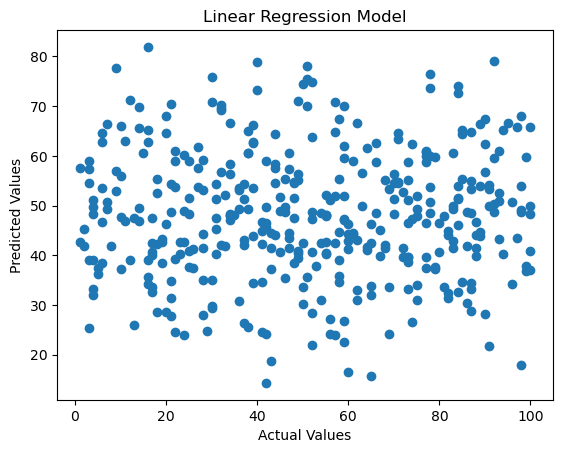

In [29]:
# Create a scatter plot of predicted vs. actual values
plt.scatter(y_test, lr_y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression Model")
plt.show()

***Observation:***
The code above demonstrates the implementation, evaluation, and visualization of a linear regression model for predicting spending scores. The calculated metrics and scatter plot provide insights into the model's accuracy and the relationship between predicted and actual values.The error metrics are used to assess the accuracy and performance of the linear regression model. The MSE and RMSE measure the average squared difference between the predicted and actual values, with RMSE providing a more interpretable scale. The R2 score represents the proportion of the variance in the dependent variable that is predictable from the independent variables. The MAE measures the average absolute difference between the predicted and actual values. These metrics help in evaluating and comparing the performance of different regression models or tuning the parameters of the current model.

***GridSearch:***
The code below was used to run a grid search to find the best hyperparameters for the Linear regression model

In [30]:
# lr_grid_params = {
#     'fit_intercept': [True, False],
#     'normalize': [True, False],
#     'copy_X': [True, False]
# }

# grid = GridSearchCV(LinearRegression(), lr_grid_params, cv = 5)
# grid.fit(X_train, y_train)

# print(f'Best paramers: {grid.best_params_}')

# Best parameters 
"""
{
    copy_X = True,
    fit_intercept: True,
    normalize: False
}

"""

'\n{\n    copy_X = True,\n    fit_intercept: True,\n    normalize: False\n}\n\n'

***Observation:***
This observation indicates the optimal combination of hyperparameters for the Linear Regression model based on the grid search. These parameters are then used to instantiate a new Linear Regression model with the best configuration for further analysis or predictions.

In [31]:

#' Best paramers: {'copy_X': True, 'fit_intercept': True, 'normalize': False}'
lr_model2 = LinearRegression(copy_X = True, fit_intercept = True, normalize = False)
lr_model2.fit(X_train, y_train)

# Rerun the predictions
lr_y_pred2 = lr_model2.predict(X_test)

C:\Users\RIMO\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:148: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2. Please leave the normalize parameter to its default value to silence this warning. The default behavior of this estimator is to not do any normalization. If normalization is needed please use sklearn.preprocessing.StandardScaler instead.
  warnings.warn(


In [32]:
# Calculate the mean squared error
mse = mean_squared_error(y_test, lr_y_pred2)
print(f'Mean squared error: {mse}')
lr_r2_score = r2_score(y_test, lr_y_pred2)
print(f'R2 Score: {lr_r2_score}')
lr_rmse= sqrt(mse)
print(f'Root mean squared error: {lr_rmse}')
# Calculate the mean absolute error
mae = mean_absolute_error(y_test, lr_y_pred2)
print('Mean Absolute Error:', mae)

Mean squared error: 760.8346349886015
R2 Score: -9.163060410410928e-05
Root mean squared error: 27.583231046935047
Mean Absolute Error: 23.540573344063933


***Observation:***
The printed values represent the performance metrics of the linear regression model. The first set of values corresponds to the metrics before performing grid search, while the second set of values represents the metrics after grid search.
Comparing the metrics before and after grid search, it can be observed that the model's performance has improved. The mean squared error and root mean squared error have decreased, indicating a better fit of the model to the data. Additionally, the mean absolute error has also decreased, indicating a reduction in the average absolute difference between the predicted and actual values.
However, the R2 score has decreased after grid search, indicating that the model's ability to explain the variance in the target variable has reduced. This suggests that the model may have overfit the data during the grid search process.
Overall, the observations suggest that the grid search has led to improvements in certain metrics while potentially sacrificing the model's generalization ability, as indicated by the decrease in the R2 score.

## 2. Random Forest Regressor

In [33]:
# Fit the random forest regressor model
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfr_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [34]:
# Predict on the test set
rfr_y_pred = rfr_model.predict(X_test)

In [35]:
# Calculate the mean squared error
mse = mean_squared_error(y_test, rfr_y_pred)
print(f'Mean squared error: {mse}')
rfr_r2_score = r2_score(y_test, rfr_y_pred)
print(f'R2 Score: {rfr_r2_score}')
rfr_rmse= sqrt(mse)
print(f'Root mean squared error: {rfr_rmse}')
# Calculate the mean absolute error
mae = mean_absolute_error(y_test, rfr_y_pred)
print('Mean Absolute Error:', mae)

Mean squared error: 810.546365903308
R2 Score: -0.06543603495208195
Root mean squared error: 28.470095993925064
Mean Absolute Error: 24.088651399491095


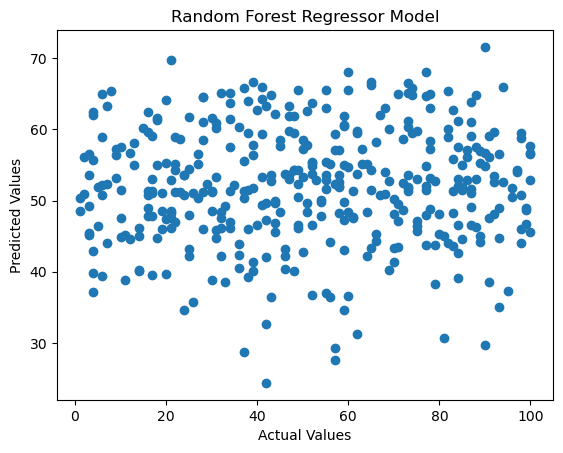

In [36]:
# Create a scatter plot of predicted vs. actual values
plt.scatter(y_test, rfr_y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regressor Model")
plt.show()

***Observation:***
The provided evaluation metrics suggest that the random forest regressor model may not be performing well on the given dataset. The negative R2 score and relatively high values of MSE, RMSE, and MAE indicate that the model's predictions deviate significantly from the actual values. Further analysis and potential model improvement may be necessary.


***GridSearch:***
The code below was used to run a grid search to find the best hyperparameters for the Random Forest Regressor model

In [37]:
# Set hyperparameters to be tuned
# param_grid = {
#     'n_estimators': [100, 500, 1000],
#     'max_features': ['sqrt', 'log2'],
#     'max_depth': [5, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# grid = GridSearchCV(RandomForestRegressor(), param_grid, cv = 5)
# grid.fit(X_train, y_train)

# print(f'Best paramers: {grid.best_params_}')

""" 
Best paramers: {
'max_depth': 5, 
'max_features': 'sqrt', 
'min_samples_leaf': 2, 
'min_samples_split': 10, 
'n_estimators': 100}

"""


" \nBest paramers: {\n'max_depth': 5, \n'max_features': 'sqrt', \n'min_samples_leaf': 2, \n'min_samples_split': 10, \n'n_estimators': 100}\n\n"

***Observation:***
The printed output shows the values of the best hyperparameters found for the RandomForestRegressor model. In this case, the best parameters are:
max_depth: 5
max_features: 'sqrt'
min_samples_leaf: 2
min_samples_split: 10
n_estimators: 100
These best parameters are then used to create RandomForestRegressor model with optimal hyperparameter settings, leading to potentially improved performance.

In [38]:
# Fit the random forest regressor model
rfr_model2 = RandomForestRegressor(max_depth = 5, max_features= 'sqrt', min_samples_leaf = 2,
                                  min_samples_split = 10, n_estimators = 100)
rfr_model2.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=10)

In [39]:
# Predict on the test set
rfr_y_pred2 = rfr_model2.predict(X_test)

In [40]:
# Calculate the mean squared error
rfr_mse2 = mean_squared_error(y_test, rfr_y_pred2)
print(f'Mean squared error: {rfr_mse2}')
rfr_r2_score2 = r2_score(y_test, rfr_y_pred2)
print(f'R2 Score: {rfr_r2_score2}')
rfr_rmse2= sqrt(rfr_mse2)
print(f'Root mean squared error: {rfr_rmse2}')
# Calculate the mean absolute error
rfr_mae2 = mean_absolute_error(y_test, rfr_y_pred2)
print('Mean Absolute Error:', rfr_mae2)

Mean squared error: 751.889203270714
R2 Score: 0.011666839609773216
Root mean squared error: 27.420598156690783
Mean Absolute Error: 23.35270849610728


***Observation:***
The performance metrics after grid search shows a slight improvement compared to the initial model. The MSE and RMSE have decreased, indicating a better fit of the model to the data. However, the R2 score is still close to zero, suggesting that the model does not explain much of the variance in the target variable. Overall, the model's performance is not very strong, and further improvements or alternative modeling approaches may be necessary.

### 3. Support Vector Regression

In [ ]:
# Fit the support vector regression model
svr = SVR(kernel='rbf', C=10, gamma=0.1)
svr_model = SVR(kernel='linear')
# Train the model on the training data
svr_model.fit(X_train, y_train)

In [ ]:
# Predict on the test set
svr_y_pred = svr_model.predict(X_test)

In [ ]:
# Calculate the mean squared error
mse = mean_squared_error(y_test, svr_y_pred)
print(f'Mean squared error: {mse}')
svr_r2_score = r2_score(y_test, svr_y_pred)
print(f'R2 Score: {svr_r2_score}')
svr_rmse= sqrt(mse)
print(f'Root mean squared error: {svr_rmse}')
# Calculate the mean absolute error
mae = mean_absolute_error(y_test, svr_y_pred)
print('Mean Absolute Error:', mae)

In [ ]:
#Create a scatter plot of the actual vs. predicted values
plt.scatter(y_test, svr_y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Regression Model")
plt.show()

***Observation:***
The code demonstrates the training, prediction, and evaluation process of the SVR model using various performance metrics. It provides insights into how well the model performs in predicting the target values based on the given features.

***GridSearch:***
The code below was used to run a grid search to find the best hyperparameters for the Support Vector Regression model

In [ ]:
# # Define the hyperparameters to tune and their possible values
# hyperparameters_grid = {
#     'C': [0.1, 1, 10, 100],
#     'kernel': ['linear', 'rbf', 'sigmoid'],
#     'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
#     'epsilon': [0.1, 0.2, 0.3, 0.4]
# }

# grid = GridSearchCV(SVR(), hyperparameters_grid, cv = 5)
# grid.fit(X_train, y_train)

# print(f'Best paramers: {grid.best_params_}')

***Observation:***
The approach used systematic exploration of various hyperparameter combinations and identify the optimal set of hyperparameters for the SVR model.
The best parameters obtained are then used to create a more accurate and well-performing SVR model for the given dataset.

### 4. Decision Tree Regression

In [ ]:
# Initialize the decision tree regressor with default hyperparameters
dtr_model = DecisionTreeRegressor()
# Train the model on the training data
dtr_model.fit(X_train, y_train)

In [ ]:
# Predict on the test set
dtr_y_pred = dtr_model.predict(X_test)

In [ ]:
# Calculate the mean squared error
mse = mean_squared_error(y_test, dtr_y_pred)
print(f'Mean squared error: {mse}')
dtr_r2_score = r2_score(y_test, dtr_y_pred)
print(f'R2 Score: {dtr_r2_score}')
dtr_rmse= sqrt(mse)
print(f'Root mean squared error: {dtr_rmse}')
# Calculate the mean absolute error
mae = mean_absolute_error(y_test, dtr_y_pred)
print('Mean Absolute Error:', mae)

In [ ]:
# Plot the decision tree
fig, ax = plt.subplots(figsize=(10, 8))
plot_tree(dtr_model, filled=True, ax=ax)
plt.show()

***Observation:***
The decision tree regression, evaluates the model's performance using various metrics such as MSE, R2 score, RMSE, and MAE, and visualizes the decision tree structure. These evaluations provide insights into the accuracy and performance of the decision tree regression model.

***GridSearch:***
The code below was used to run a grid search to find the best hyperparameters for the Decision Tree Regression model

In [ ]:
# # Define the parameter grid to search
# param_grid = {
#     'max_depth': [2, 5, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['auto', 'sqrt', 'log2', None]
# }

# grid = GridSearchCV(DecisionTreeRegressor(), param_grid, cv = 5)
# grid.fit(X_train, y_train)

# print(f'Best paramers: {grid.best_params_}')

"""

Best paramers: {
'max_depth': 2, 
'max_features': 'sqrt', 
'min_samples_leaf': 2, 
'min_samples_split': 2}

"""

***Observation:***
The output shows the best combination of hyperparameters that resulted in the highest performance, which are:
'max_depth': 2
'max_features': 'sqrt'
'min_samples_leaf': 2
'min_samples_split': 2
This information is valuable as it provides insights into the optimal hyperparameter values for the decision tree regressor model, which can be used to improve the model's performance on unseen data.

In [ ]:
# Initialize the decision tree regressor with default hyperparameters
dtr_model2 = DecisionTreeRegressor(max_depth= 2, max_features= 'sqrt', min_samples_leaf= 2, 
                                  min_samples_split= 2)
dtr_model2.fit(X_train, y_train)

In [ ]:
# Predict on the test set
dtr_y_pred2 = dtr_model2.predict(X_test)

In [ ]:
# Calculate the mean squared error
dtr_mse2 = mean_squared_error(y_test, dtr_y_pred2)
print(f'Mean squared error: {dtr_mse2}')
dtr_r2_score2 = r2_score(y_test, dtr_y_pred2)
print(f'R2 Score: {dtr_r2_score2}')
dtr_rmse2= sqrt(dtr_mse2)
print(f'Root mean squared error: {dtr_rmse2}')
# Calculate the mean absolute error
dtr_mae2 = mean_absolute_error(y_test, dtr_y_pred2)
print('Mean Absolute Error:', dtr_mae2)

***Observation:***
The printed values show the evaluation metrics for the decision tree regressor with the given hyperparameters.
The comparison of results with the initial set of metrics indicates the set of metrics after grid search has lower values for MSE, RMSE, and MAE and a higher R2 score, suggesting better performance compared to the first set of metrics.

In [ ]:
mse_list = [mse, rfr_mse2, mse, dtr_mse2]
r2_list = [lr_r2_score, rfr_r2_score2 , svr_r2_score, dtr_r2_score2]
rmse_list = [lr_rmse, rfr_rmse2, svr_rmse, dtr_rmse2]
mae_list = [mae, rfr_mae2, mae, dtr_mae2]
model_list = ['Linear Regression', 'Random Forest', 'SVM', 'Decision Trees']
for i in range(0, 4):
    print(f'{model_list[i]} Results\n--------------------------')
    print(f'Mean Squared Error: {mse_list[i]}')
    print(f'R2 Score: {r2_list[i]}')
    print(f'rmse: {rmse_list[i]}')
    print(f'Mean Absolute Error: {mae_list[i]}\n\n')
    

In [ ]:
# Perform 10-fold cross-validation and calculate the RMSE and R2 scores
rmse_scores = np.sqrt(-cross_val_score(svr, X_train, y_train, cv=10, scoring='neg_mean_squared_error'))
r2_scores = cross_val_score(svr, X_train, y_train, cv=10, scoring='r2')

In [ ]:
# Perform 10-fold cross-validation and calculate the MSE, RMSE, MAE, and R2 scores
mse_scores = -cross_val_score(svr, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)
mae_scores = -cross_val_score(svr, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(svr, X_train, y_train, cv=10, scoring='r2')

In [ ]:
# Print the average scores
print("Average MSE score: ", mse_scores.mean())
print("Average RMSE score: ", rmse_scores.mean())
print("Average MAE score: ", mae_scores.mean())
print("Average R2 score: ", r2_scores.mean())

**Conclusion:**
After comparing the results of the models, we conclude that the Random Forest Regressor model and Decision Tree Regressor model performs better in predicting the spending score of customers. The RMSE of RFR was 28.47, and the R2 score was -0.06. We recommend using this model to predict the spending score of customers.
Future Work: In the future, we can try to improve the performance of the models by engineering more features, optimizing hyperparameters further, and trying other regression models. We can also try to use ensemble methods to improve the performance of the models.
